##### Universidad Autónoma de Guadalajara
Aprendizaje Automatizado para la Gestión de Datos Masivos   

Profesor: Paulo López Meyer. 

Estudiante: Anayansi Cristina Hernández Abrego. 

Código vistos en clase ( tarea 09). 

In [135]:
# Enhanced Decision Tree with Friendly Visualization
# Based on diabetes prediction dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

################################# DATA HANDLING ####################################################
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("./diabetes.csv", header=None, names=col_names)

# Create more readable feature names for visualization
feature_mapping = {
    'pregnant': 'Pregnancies',
    'insulin': 'Insulin Level',
    'bmi': 'BMI',
    'age': 'Age',
    'glucose': 'Glucose Level',
    'bp': 'Blood Pressure',
    'pedigree': 'Diabetes Pedigree'
}

feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols]
y = pima.label

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
################################# MACHINE LEARNING PART (OPTIMIZADO) ####################################################
from sklearn.model_selection import GridSearchCV

# 1. Definimos el árbol base sin parámetros iniciales fijados
base_tree = DecisionTreeClassifier(random_state=1)

# 2. Creamos la "rejilla" (grid) con las opciones que queremos evaluar
# Probaremos combinaciones de criterios, profundidades y mínimos de muestras para abrir ramas
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5,6 ],
    'min_samples_split': [2, 3,6],
    'min_samples_leaf': [2, 3,4,5,6]
}

# 3. Configuramos GridSearchCV
# cv=5: Divide los datos de entrenamiento en 5 bloques para validar internamente (5-Fold Cross Validation)
# scoring='accuracy': Buscará la combinación que maximice el acierto general
grid_search = GridSearchCV(estimator=base_tree, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Entrenamos el objeto de búsqueda con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# 5. Extraemos el mejor modelo encontrado por el algoritmo
clf = grid_search.best_estimator_

# Imprimimos los hiperparámetros ganadores
print("="*60)
print("MEJORES PARÁMETROS ENCONTRADOS")
print("="*60)
print(f"Criterio óptimo: {grid_search.best_params_['criterion']}")
print(f"Profundidad óptima (max_depth): {grid_search.best_params_['max_depth']}")
print(f"Mínimo para split (min_samples_split): {grid_search.best_params_['min_samples_split']}")
print(f"Mínimo en hojas (min_samples_leaf): {grid_search.best_params_['min_samples_leaf']}")
print(f"Mejor precisión en validación cruzada: {grid_search.best_score_:.2%}")
print("="*60)

# 6. Evaluamos el modelo final con el conjunto de prueba (X_test)
y_pred = clf.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Model Accuracy Final (Test Set): {accuracy:.2%}")


MEJORES PARÁMETROS ENCONTRADOS
Criterio óptimo: entropy
Profundidad óptima (max_depth): 6
Mínimo para split (min_samples_split): 2
Mínimo en hojas (min_samples_leaf): 10
Mejor precisión en validación cruzada: 75.61%
Model Accuracy Final (Test Set): 75.76%


In [ ]:

################################# MACHINE LEARNING PART ####################################################
# Create a simpler tree for better visualization (limit depth)
clf = DecisionTreeClassifier() # <===== OPTIMIZAR AQUI, Incluir los argumentos "criterion" y "max_depth" de acuerdo a la documentacion en https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
#
#Mejora 1
#clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=1)
# Mejora 2
clf = DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_split=6,min_samples_leaf= 2, random_state=1)

clf = clf.fit(X_train, y_train)
# Predictions and accuracy
y_pred = clf.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")


Model Accuracy: 79.65%


/var/folders/27/1bvxggm90wnbrqhnl_7x9p6h0000gn/T/ipykernel_85745/1192621294.py:17: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/27/1bvxggm90wnbrqhnl_7x9p6h0000gn/T/ipykernel_85745/1192621294.py:18: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  plt.savefig('friendly_decision_tree.png', dpi=300, bbox_inches='tight')
/Users/anayansihernandez/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


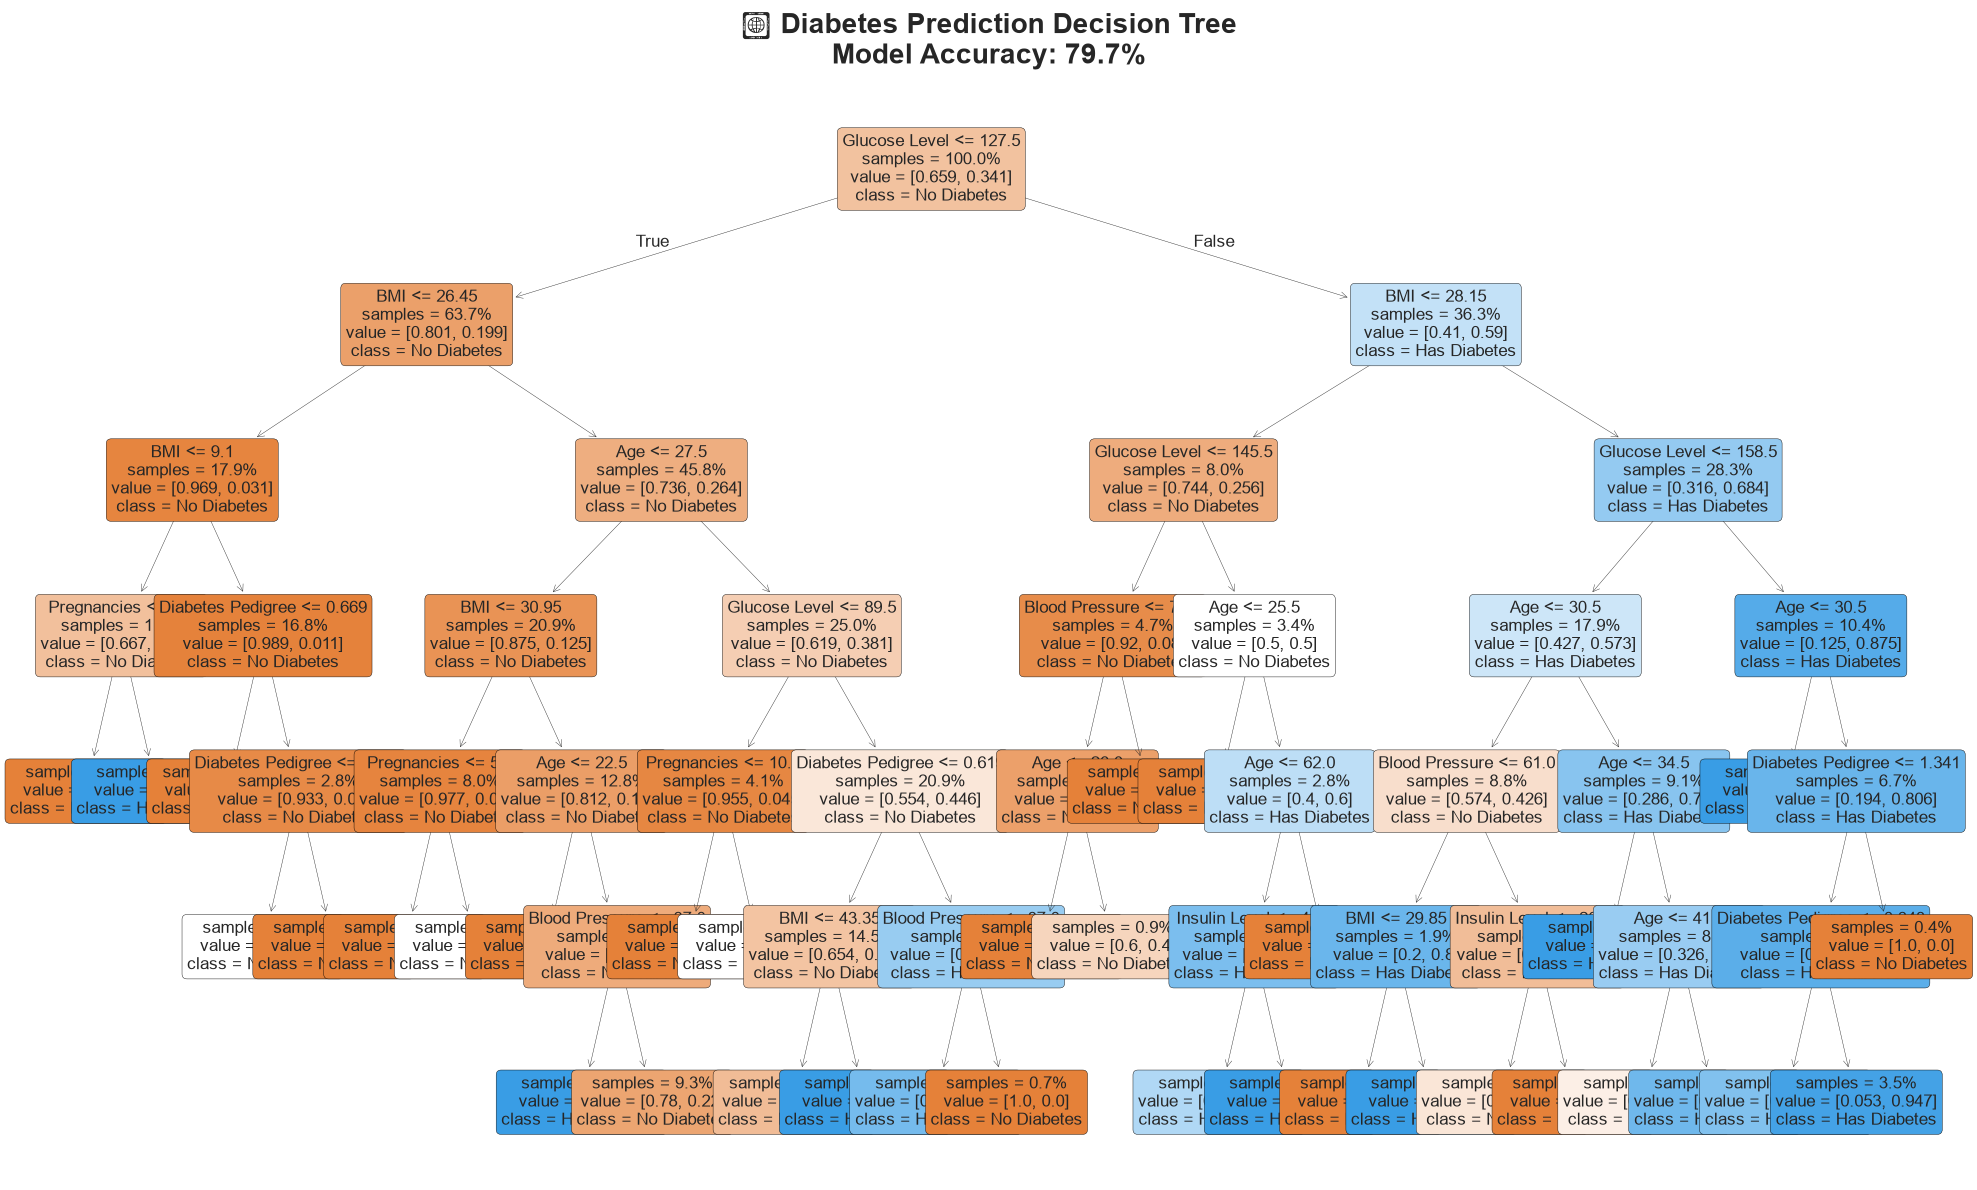

In [147]:

#################################  VISUALIZATION ####################################################

# 1. Beautiful Decision Tree Plot
plt.figure(figsize=(20, 12))
plot_tree(clf, 
          feature_names=[feature_mapping[col] for col in feature_cols],
          class_names=['No Diabetes', 'Has Diabetes'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=True,
          impurity=False)

plt.title('🌳 Diabetes Prediction Decision Tree\n'
          f'Model Accuracy: {accuracy:.1%}', 
          fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('friendly_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/27/1bvxggm90wnbrqhnl_7x9p6h0000gn/T/ipykernel_85745/2233473729.py:15: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/27/1bvxggm90wnbrqhnl_7x9p6h0000gn/T/ipykernel_85745/2233473729.py:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
/Users/anayansihernandez/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


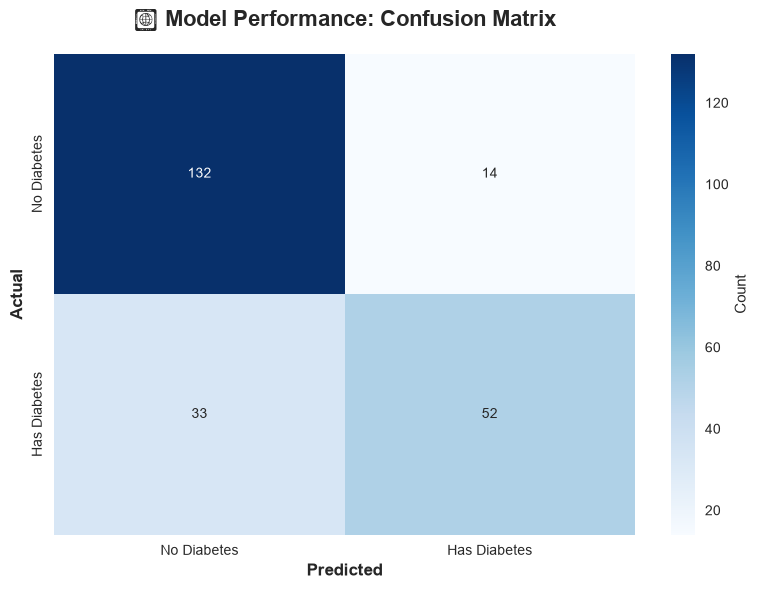

In [148]:

# 2. Model Performance Visualization
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Count'})
plt.title('🎯 Model Performance: Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [149]:

# 3. Summary Statistics
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Accuracy: {accuracy:.1%}")
print(f"Tree Depth: {clf.tree_.max_depth}")
print(f"Number of Leaves: {clf.tree_.n_leaves}")
print(f"Total Samples: {len(X)}")
print(f"Test Samples: {len(X_test)}")

# 4. Classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Has Diabetes']))


MODEL SUMMARY
Accuracy: 79.7%
Tree Depth: 6
Number of Leaves: 34
Total Samples: 768
Test Samples: 231

📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.90      0.85       146
Has Diabetes       0.79      0.61      0.69        85

    accuracy                           0.80       231
   macro avg       0.79      0.76      0.77       231
weighted avg       0.80      0.80      0.79       231

